In [1]:
# ============================================================
# CELL 1: Install Dependencies — PINNED VERSIONS
# ============================================================
# Same discipline as Projects 1 & 2: pin versions, don't use
# "latest". If this is a fresh Kaggle session, re-run this cell.
# Locally, these should already be in your venv.
# ============================================================

!pip install -q \
    "openai>=1.50.0" \
    "datasketch==1.6.5" \
    "jsonschema==4.23.0" \
    "pydantic>=2.7.0" \
    "datasets>=2.18.0" \
    "huggingface_hub>=0.23.0" \
    "nest_asyncio==1.6.0" \
    "python-dotenv>=1.0.0" \
    pandas tqdm matplotlib tabulate

print("✅ Dependencies installed.")

# Verify the critical versions
import openai, datasketch, pydantic, datasets
print(f"openai:        {openai.__version__}")
print(f"datasketch:    {datasketch.__version__}")
print(f"pydantic:      {pydantic.VERSION}")
print(f"datasets:      {datasets.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.2/89.2 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 3.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
✅ Dependencies installed.
openai:        2.23.0
datasketch:    1.6.5
pydantic:      2.12.3
datasets:      4.8.3


In [4]:
# ============================================================
# DAY 7 — CELL 2: Configuration — One Source of Truth
# ============================================================
# Every constant used downstream lives here. Change behavior by
# editing this cell and no others.
#
# SEED = 42 (matches Projects 1 & 2 for consistency).
#
# MAX_CONCURRENT = 10:
#   OpenAI Tier 1 defaults: 500 RPM, 200K TPM for gpt-4o-mini.
#   At 10 concurrent × ~3s/call = ~200 RPM — well under the limit.
#   If you're on the free tier (3 RPM!), drop this to 2.
#
# N_EXAMPLES = 1200:
#   Target a visible survival rate after filtering. Expect 60-75%
#   yield, so 1200 generated → ~800 clean. Enough to demonstrate
#   the pipeline without spending real money.
# ============================================================
import os
import json
import hashlib
import asyncio
import statistics
from datetime import datetime
from pathlib import Path

import pandas as pd
import numpy as np
from tqdm.asyncio import tqdm_asyncio
from tqdm import tqdm

# Load API key
# Kaggle path:
try:
    from kaggle_secrets import UserSecretsClient
    OPENAI_API_KEY = UserSecretsClient().get_secret("OPENAI_API_KEY")
    print("✅ Loaded OPENAI_API_KEY from Kaggle secrets.")
except Exception:
    # Local path
    from dotenv import load_dotenv
    load_dotenv()
    OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY")
    if OPENAI_API_KEY:
        print("✅ Loaded OPENAI_API_KEY from .env.")
    else:
        raise RuntimeError(
            "❌ No OPENAI_API_KEY found. Set it in Kaggle secrets "
            "or put it in a local .env file."
        )

# Global constants
SEED              = 42
MODEL             = "gpt-4o-mini"
N_EXAMPLES        = 1200
MAX_CONCURRENT    = 10
MAX_RETRIES       = 5       # OpenAI SDK built-in; applied on every request
REQUEST_TIMEOUT   = 60.0    # seconds; gpt-4o-mini typically responds <10s

# Output directories
DATA_DIR      = Path("./data")
RAW_DIR       = DATA_DIR / "raw"
FILTERED_DIR  = DATA_DIR / "filtered"
FINAL_DIR     = DATA_DIR / "final"
RESULTS_DIR   = Path("./results")
for d in [RAW_DIR, FILTERED_DIR, FINAL_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

np.random.seed(SEED)

print(f"\nConfig:")
print(f"  Model:           {MODEL}")
print(f"  N examples:      {N_EXAMPLES}")
print(f"  Max concurrent:  {MAX_CONCURRENT}")
print(f"  SDK retries:     {MAX_RETRIES}")
print(f"  Seed:            {SEED}")

✅ Loaded OPENAI_API_KEY from Kaggle secrets.

Config:
  Model:           gpt-4o-mini
  N examples:      1200
  Max concurrent:  10
  SDK retries:     5
  Seed:            42


In [6]:
# ============================================================
# DAY 7 — CELL 3: Prompt Templates and Topic Set
# ============================================================
# Diversity note: the final dataset is only as diverse as the
# prompts that generate it. A single template + single topic
# produces a uniform dataset that trains a model to overfit one
# style. We use:
#   - 4 templates (different task framings)
#   - 12 topics (spanning programming, ML, and software systems)
# = 48 (template × topic) combinations, each generating ~25
# examples at N=1200. That's enough variation that near-dedup
# will still find clusters but the surviving set covers real
# terrain.
#
# Each template asks for PREFERENCE data: a prompt, a good
# response ("chosen"), and a subtly worse response ("rejected").
# "Subtly worse" is important — if rejected is obvious garbage,
# the pair is useless for RLHF/DPO training.
# ============================================================

PROMPT_TEMPLATES = [
    # T1 — Factual explanation
    ("""You are generating a training example for a preference-learning dataset.

Topic: {topic}

Produce:
  - prompt: a specific, well-formed user question about {topic} (one sentence)
  - chosen: an accurate, clear, 2-4 sentence answer
  - rejected: a plausible-sounding answer that contains a SUBTLE factual error or overlooks an important nuance

The chosen and rejected answers should be similar in length and tone. The error in rejected must be subtle enough that someone unfamiliar with {topic} might not notice.""", "T1"),

    # T2 — Step-by-step reasoning
    ("""You are generating a training example for a preference-learning dataset.

Domain: {topic}

Produce:
  - prompt: a question that requires step-by-step reasoning in {topic}
  - chosen: a response with 3-5 correct reasoning steps leading to the right answer
  - rejected: a response with similar structure but containing one plausible-looking logical error in the reasoning chain

Keep both responses roughly equal in length.""", "T2"),

    # T3 — Code / technical how-to
    ("""You are generating a training example for a preference-learning dataset.

Technical area: {topic}

Produce:
  - prompt: a specific "how do I..." question about {topic}
  - chosen: a concise, correct solution or explanation (include a short code snippet if relevant)
  - rejected: a solution that runs / sounds right but has a subtle bug, off-by-one, or uses a deprecated API

The rejected response must look plausible at a glance.""", "T3"),

    # T4 — Debugging / diagnosis
    ("""You are generating a training example for a preference-learning dataset.

Subject: {topic}

Produce:
  - prompt: a short description of a bug, error, or unexpected behavior in {topic}
  - chosen: a correct diagnosis and fix
  - rejected: a diagnosis that addresses a real but different possible cause, or a fix that works only for the symptom

Keep both responses equal in length and tone.""", "T4"),
]

TOPICS = [
    "Python programming",
    "SQL queries",
    "data structures",
    "algorithm complexity",
    "machine learning fundamentals",
    "neural network training",
    "software design patterns",
    "debugging strategies",
    "REST API design",
    "database indexing",
    "distributed systems",
    "version control with Git",
]

print(f"Templates: {len(PROMPT_TEMPLATES)}")
print(f"Topics:    {len(TOPICS)}")
print(f"Combinations: {len(PROMPT_TEMPLATES) * len(TOPICS)}")
print(f"Examples per combination (avg): {N_EXAMPLES / (len(PROMPT_TEMPLATES) * len(TOPICS)):.1f}")

Templates: 4
Topics:    12
Combinations: 48
Examples per combination (avg): 25.0


In [7]:
# ============================================================
# DAY 7 — CELL 4: Pydantic Output Schema
# ============================================================
# This is the crucial improvement over the master context doc's
# approach. Instead of:
#   1. Asking the model to "return JSON"
#   2. Stripping ```json``` code fences
#   3. Calling json.loads() and hoping
#
# ...we define a Pydantic model and pass it to
# `client.chat.completions.parse()`. OpenAI's Structured Outputs
# feature guarantees the response conforms exactly to this schema.
# Parse failure rate on gpt-4o-mini drops from ~15% (prompt-based
# JSON) to <1% (structured outputs).
#
# Field descriptions double as prompts to the model — writing
# good descriptions improves output quality.
# ============================================================

from pydantic import BaseModel, Field

class PreferenceExample(BaseModel):
    prompt: str = Field(
        ...,
        description="The user question or instruction. One or two sentences.",
    )
    chosen: str = Field(
        ...,
        description="The higher-quality, accurate response. 2-5 sentences.",
    )
    rejected: str = Field(
        ...,
        description="The lower-quality response with a subtle error or omission. 2-5 sentences, similar length to chosen.",
    )

print("✅ PreferenceExample schema defined.")
print(PreferenceExample.model_json_schema())

✅ PreferenceExample schema defined.
{'properties': {'prompt': {'description': 'The user question or instruction. One or two sentences.', 'title': 'Prompt', 'type': 'string'}, 'chosen': {'description': 'The higher-quality, accurate response. 2-5 sentences.', 'title': 'Chosen', 'type': 'string'}, 'rejected': {'description': 'The lower-quality response with a subtle error or omission. 2-5 sentences, similar length to chosen.', 'title': 'Rejected', 'type': 'string'}}, 'required': ['prompt', 'chosen', 'rejected'], 'title': 'PreferenceExample', 'type': 'object'}


In [8]:
# ============================================================
# DAY 7 — CELL 5: The Async Generator
# ============================================================
# DESIGN NOTES (read before modifying):
#
# 1. AsyncOpenAI: the SDK ships with both sync (OpenAI) and
#    async (AsyncOpenAI) clients. Use the async client so N
#    calls can be in flight concurrently.
#
# 2. `max_retries=5`: OpenAI SDK v1.50+ does exponential-backoff
#    retries automatically for network errors, 408, 409, 429,
#    and 500+ status codes. This is why we don't need tenacity.
#
# 3. `timeout=60`: one request should finish in <10s for
#    gpt-4o-mini at 600 tokens. 60s gives margin for retries.
#
# 4. asyncio.Semaphore(MAX_CONCURRENT): bounds in-flight calls.
#    Even with 1000 generated tasks, only 10 are ever active.
#    Prevents blowing through the rate limit.
#
# 5. nest_asyncio.apply(): Jupyter/Kaggle already run an event
#    loop. `asyncio.run()` inside an event loop raises
#    `RuntimeError: This event loop is already running`.
#    `nest_asyncio` patches asyncio to allow re-entry.
#
# 6. Every call is tagged with `template_id`, `topic`,
#    `timestamp`, and a `prompt_hash` (MD5 of the generated
#    prompt). prompt_hash is used for exact-dedup on Day 8.
# ============================================================

import nest_asyncio
nest_asyncio.apply()

from openai import AsyncOpenAI

client = AsyncOpenAI(
    api_key      = OPENAI_API_KEY,
    max_retries  = MAX_RETRIES,
    timeout      = REQUEST_TIMEOUT,
)


async def generate_one(
    template_text: str,
    template_id:   str,
    topic:         str,
    semaphore:     asyncio.Semaphore,
) -> dict | None:
    """
    Generate one synthetic preference example.
    Returns a dict, or None on failure (after SDK retries exhausted).
    """
    async with semaphore:
        user_msg = template_text.format(topic=topic)

        try:
            # Structured Outputs: model must return a JSON object
            # that validates against PreferenceExample.
            response = await client.chat.completions.parse(
                model           = MODEL,
                messages        = [{"role": "user", "content": user_msg}],
                response_format = PreferenceExample,
                max_tokens      = 800,
                temperature     = 0.8,   # moderate diversity; 1.0+ drifts off-topic
            )
            parsed: PreferenceExample | None = response.choices[0].message.parsed

            # .parsed can still be None if the model refused or
            # the response was truncated before validation finished.
            if parsed is None:
                return None

            record = parsed.model_dump()
            record.update({
                "template_id":           template_id,
                "topic":                 topic,
                "model":                 MODEL,
                "generation_timestamp":  datetime.utcnow().isoformat(timespec="seconds") + "Z",
                "prompt_hash":           hashlib.md5(record["prompt"].encode()).hexdigest(),
                "finish_reason":         response.choices[0].finish_reason,
                "usage_input_tokens":    response.usage.prompt_tokens,
                "usage_output_tokens":   response.usage.completion_tokens,
            })
            return record

        except Exception as e:
            # Don't crash the whole run on one bad call. Count
            # failures in the outer loop.
            return {"_error": type(e).__name__, "_msg": str(e)[:200],
                    "template_id": template_id, "topic": topic}


async def generate_batch(n_examples: int, max_concurrent: int) -> list[dict]:
    """Fan out n_examples calls, bounded at max_concurrent."""
    semaphore = asyncio.Semaphore(max_concurrent)

    tasks = []
    for i in range(n_examples):
        template_text, template_id = PROMPT_TEMPLATES[i % len(PROMPT_TEMPLATES)]
        topic                       = TOPICS[i % len(TOPICS)]
        tasks.append(generate_one(template_text, template_id, topic, semaphore))

    results = await tqdm_asyncio.gather(*tasks, desc="Generating", unit="ex")
    return results


print("✅ Generator functions defined.")

✅ Generator functions defined.


In [9]:
# ============================================================
# DAY 7 — CELL 6: Run the Generation Loop
# ============================================================
# Expected runtime for N=1200 at 10 concurrent:
#   1200 / 10 × ~3s/call = ~360s ≈ 6 minutes + retries.
#   Total usually ~8-12 minutes.
#
# Watch the tqdm progress bar. If it stalls, the API might be
# rate-limiting (you'd see 429 errors in the _error field).
# Lower MAX_CONCURRENT and rerun only the failed ones.
# ============================================================

print(f"Generating {N_EXAMPLES} examples using {MODEL}...")
t0 = datetime.now()
results = asyncio.run(generate_batch(N_EXAMPLES, MAX_CONCURRENT))
elapsed = (datetime.now() - t0).total_seconds()

# Split into successes and errors
successes = [r for r in results if r is not None and "_error" not in r]
errors    = [r for r in results if r is not None and "_error" in r]
nones     = [r for r in results if r is None]

print(f"\nTime:                       {elapsed:.1f}s")
print(f"Successful generations:     {len(successes)} / {N_EXAMPLES} "
      f"({len(successes)/N_EXAMPLES*100:.1f}%)")
print(f"Failed (SDK retries used):  {len(errors)}")
print(f"Parsed-None (model refused):{len(nones)}")

# Save raw successes
raw_df = pd.DataFrame(successes)
raw_csv = RAW_DIR / "raw_generated.csv"
raw_df.to_csv(raw_csv, index=False)
print(f"\n✅ Saved {len(raw_df)} raw examples → {raw_csv}")

# Save errors (for debugging)
if errors:
    err_df = pd.DataFrame(errors)
    err_csv = RAW_DIR / "generation_errors.csv"
    err_df.to_csv(err_csv, index=False)
    print(f"   Errors logged → {err_csv}")
    # Quick summary
    print("   Error breakdown:")
    print(err_df["_error"].value_counts().to_string())

# Cost tally (actual, not estimated)
total_input   = raw_df["usage_input_tokens"].sum()
total_output  = raw_df["usage_output_tokens"].sum()
# gpt-4o-mini pricing check these at platform.openai.com/docs/pricing
COST_INPUT_PER_M  = 0.15   # USD per 1M input tokens
COST_OUTPUT_PER_M = 0.60   # USD per 1M output tokens
total_cost = (total_input / 1e6 * COST_INPUT_PER_M) + (total_output / 1e6 * COST_OUTPUT_PER_M)
print(f"\n   Tokens used:  {total_input:,} input + {total_output:,} output")
print(f"   Estimated cost: ${total_cost:.3f}")

Generating 1200 examples using gpt-4o-mini...


Generating:   0%|          | 0/1200 [00:00<?, ?ex/s]/tmp/ipykernel_55/2747601308.py:78: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "generation_timestamp":  datetime.utcnow().isoformat(timespec="seconds") + "Z",
Generating: 100%|██████████| 1200/1200 [08:01<00:00,  2.49ex/s]


Time:                       481.5s
Successful generations:     1200 / 1200 (100.0%)
Failed (SDK retries used):  0
Parsed-None (model refused):0

✅ Saved 1200 raw examples → data/raw/raw_generated.csv

   Tokens used:  257,000 input + 265,889 output
   Estimated cost: $0.198


In [10]:
# ============================================================
# DAY 7 — CELL 7: Spot-Check 3 Random Examples
# ============================================================
# Before ending Day 7, eyeball a handful of examples. If they're
# obviously bad (chosen == rejected, or both are nonsense),
# there's no point continuing to Day 8. Catch it now.
# ============================================================

if len(raw_df) == 0:
    raise RuntimeError("❌ Zero successful generations. Check errors CSV, fix, rerun.")

sample = raw_df.sample(min(3, len(raw_df)), random_state=SEED)
for i, row in enumerate(sample.itertuples(), 1):
    print(f"\n══════ Example {i} ({row.template_id}, topic={row.topic}) ══════")
    print(f"PROMPT:   {row.prompt}")
    print(f"CHOSEN:   {row.chosen[:200]}{'...' if len(row.chosen) > 200 else ''}")
    print(f"REJECTED: {row.rejected[:200]}{'...' if len(row.rejected) > 200 else ''}")

print("\n📝 Visual check: chosen and rejected should be DIFFERENT text, "
      "similar length, both about the topic. If they're identical or one is empty, "
      "there's a template problem — fix Cell 3 and re-run Cell 6.")


══════ Example 1 (T3, topic=data structures) ══════
PROMPT:   How do I reverse a linked list in Python?
CHOSEN:   To reverse a linked list in Python, you can iterate through the list while changing the next pointers of each node. Here’s a simple implementation:

```python
class Node:
    def __init__(self, data):...
REJECTED: To reverse a linked list in Python, you can traverse the list while adjusting the next pointers. Here's a commonly used method:

```python
class Node:
    def __init__(self, data):
        self.data =...

══════ Example 2 (T2, topic=SQL queries) ══════
PROMPT:   How would you write a SQL query to find the average order amount from the 'orders' table for customers in the 'customers' table who live in 'New York'?
CHOSEN:   First, I will join the 'orders' table with the 'customers' table on the customer ID. Next, I will filter the results to include only those customers whose city is 'New York'. Then, I will select the o...
REJECTED: I will start by selecting data f

In [11]:
# ============================================================
# DAY 7 — CELL 8: Day 7 Checkpoint
# ============================================================
import os

required = [str(RAW_DIR / "raw_generated.csv")]
print("=" * 60)
print("DAY 7 COMPLETE — CHECKPOINT SUMMARY")
print("=" * 60)
for f in required:
    print(f"   {'✅' if os.path.exists(f) else '❌'} {f}")

print(f"\n   Raw examples:         {len(raw_df)}")
print(f"   Success rate:         {len(raw_df)/N_EXAMPLES*100:.1f}%")
print(f"   Total API cost:       ~${total_cost:.3f}")
print(f"   Wall time:            {elapsed:.1f}s")
print(f"\n   Template distribution:")
print(raw_df["template_id"].value_counts().sort_index().to_string())
print(f"\n   Topic distribution:")
print(raw_df["topic"].value_counts().to_string())

print("\n💾 Save Version → Save & Run All before closing (captures raw_generated.csv).")
print("✅ Ready to proceed to Day 8.")
print("=" * 60)

DAY 7 COMPLETE — CHECKPOINT SUMMARY
   ✅ data/raw/raw_generated.csv

   Raw examples:         1200
   Success rate:         100.0%
   Total API cost:       ~$0.198
   Wall time:            481.5s

   Template distribution:
template_id
T1    300
T2    300
T3    300
T4    300

   Topic distribution:
topic
Python programming               100
SQL queries                      100
data structures                  100
algorithm complexity             100
machine learning fundamentals    100
neural network training          100
software design patterns         100
debugging strategies             100
REST API design                  100
database indexing                100
distributed systems              100
version control with Git         100

💾 Save Version → Save & Run All before closing (captures raw_generated.csv).
✅ Ready to proceed to Day 8.


In [27]:
# ============================================================
# DAY 8 — CELL 1: Load Raw and Initialize Funnel Tracker
# ============================================================
# Every filter step records how many examples it removed and
# why. At the end we have a full audit trail: reviewers can
# see exactly why the final dataset is N rows and not N+X.
# ============================================================
import pandas as pd
from pathlib import Path

RAW_DIR       = Path("./data/raw")
FILTERED_DIR  = Path("./data/filtered")

raw_df = pd.read_csv(RAW_DIR / "raw_generated.csv")
print(f"Loaded {len(raw_df)} raw examples.")

# The "funnel" — one row per filter stage, tracking in→out
funnel = []

def record_funnel(stage: str, df_before, df_after, note: str = ""):
    entry = {
        "stage":       stage,
        "n_in":        len(df_before),
        "n_out":       len(df_after),
        "removed":     len(df_before) - len(df_after),
        "removed_pct": round((len(df_before) - len(df_after)) / max(len(df_before), 1) * 100, 2),
        "note":        note,
    }
    funnel.append(entry)
    print(f"{stage:28s}  {entry['n_in']:5d} → {entry['n_out']:5d}  "
          f"(removed {entry['removed']:4d}, {entry['removed_pct']:5.1f}%)")
    return df_after

# Seed the funnel
record_funnel("0. raw_generated", raw_df, raw_df, "")
df = raw_df.copy()

Loaded 1200 raw examples.
0. raw_generated               1200 →  1200  (removed    0,   0.0%)


In [28]:
# ============================================================
# DAY 8 — CELL 2: Length Filter
# ============================================================
# Thresholds:
#   prompt   ≥ 20 chars  (empty/trivial prompts filtered out)
#   chosen   ≥ 60 chars  (~12 words — shorter = low info)
#   rejected ≥ 60 chars  (same)
# Also: chosen length within 3× of rejected length. If one is
# 10× the other, the "subtle error" framing failed — model
# produced a long correct answer + one-line wrong answer.
# ============================================================

MIN_PROMPT_LEN    = 20
MIN_CHOSEN_LEN    = 60
MIN_REJECTED_LEN  = 60
MAX_LEN_RATIO     = 3.0

before = df.copy()

df = df[
    (df["prompt"].str.len()   >= MIN_PROMPT_LEN) &
    (df["chosen"].str.len()   >= MIN_CHOSEN_LEN) &
    (df["rejected"].str.len() >= MIN_REJECTED_LEN)
].copy()

ratio = df["chosen"].str.len() / df["rejected"].str.len().clip(lower=1)
df = df[(ratio <= MAX_LEN_RATIO) & (ratio >= 1/MAX_LEN_RATIO)].copy()

df = record_funnel("1. length filter", before, df,
                   f"prompt≥{MIN_PROMPT_LEN}, chosen/rejected≥{MIN_CHOSEN_LEN}, ratio≤{MAX_LEN_RATIO}×")

1. length filter               1200 →  1200  (removed    0,   0.0%)


In [29]:
# ============================================================
# DAY 8 — CELL 3: Distinctness Filter
# ============================================================
# The whole point of preference data is that chosen ≠ rejected.
# If the model regurgitated the same text for both, the row is
# worthless for training.
#
# We compute word-level Jaccard similarity between chosen and
# rejected. Too high (>0.85) = nearly identical → drop.
# Too low (<0.10) = might be completely off-topic from each
# other → also drop (we want "subtle" differences, not "different
# universe" differences).
# ============================================================

def word_jaccard(a: str, b: str) -> float:
    A = set(a.lower().split())
    B = set(b.lower().split())
    if not A or not B:
        return 0.0
    return len(A & B) / len(A | B)

before = df.copy()
df["cr_jaccard"] = df.apply(lambda r: word_jaccard(r["chosen"], r["rejected"]), axis=1)
df = df[(df["cr_jaccard"] >= 0.10) & (df["cr_jaccard"] <= 0.85)].copy()

df = record_funnel("2. chosen/rejected distinct", before, df,
                   "0.10 ≤ word-Jaccard(chosen, rejected) ≤ 0.85")

print(f"\n   Distribution of chosen/rejected Jaccard (survivors):")
print(df["cr_jaccard"].describe().to_string())

2. chosen/rejected distinct    1200 →  1053  (removed  147,  12.2%)

   Distribution of chosen/rejected Jaccard (survivors):
count    1053.000000
mean        0.376950
std         0.197176
min         0.100000
25%         0.212121
50%         0.340000
75%         0.520548
max         0.850000


In [30]:
# ============================================================
# DAY 8 — CELL 4: Exact Dedup by Prompt Hash
# ============================================================
# MD5(prompt) already computed at generation time. Exact dedup
# is cheap (dict lookup) and always happens before near-dedup
# — there's no point MinHashing two identical strings.
# ============================================================
before = df.copy()
df = df.drop_duplicates(subset=["prompt_hash"]).copy()
df = record_funnel("3. exact dedup", before, df, "MD5(prompt) unique")

3. exact dedup                 1053 →   604  (removed  449,  42.6%)


In [31]:
# ============================================================
# DAY 8 — CELL 5: MinHash LSH Near-Dedup
# ============================================================
# DESIGN NOTES:
#
# 1. CHARACTER 5-GRAM SHINGLES, not word tokens.
#    Whitespace-split words are sensitive to small edits
#    (e.g. "bigger" vs "biggest") but miss paraphrasing that
#    swaps word order. Character 5-grams catch both. This is
#    standard in large-scale dedup pipelines (e.g. FineWeb).
#
# 2. threshold=0.8:
#    Jaccard similarity threshold. Empirically, 0.8 catches
#    near-duplicates that differ only in filler words, while
#    letting genuinely distinct rephrasings through.
#
# 3. num_perm=128:
#    MinHash signature length. Higher = better precision, more
#    memory. 128 is the datasketch default and plenty for <1K items.
#
# 4. BULK INSERTION SESSION:
#    `lsh.insertion_session()` is a context manager that batches
#    insertions. Much faster than individual .insert() calls for
#    any dataset over a few hundred rows.
#
# 5. "Keep first occurrence" strategy:
#    For each row, query the LSH. If it already has duplicates
#    in the index, this row is a dup — skip it. If not, insert.
#    Preserves iteration order, deterministic given SEED.
# ============================================================

from datasketch import MinHash, MinHashLSH

NEAR_DEDUP_THRESHOLD = 0.8
NUM_PERM             = 128
SHINGLE_K            = 5

def char_shingles(text: str, k: int = SHINGLE_K) -> set[str]:
    """All length-k character substrings of text (after whitespace collapse + lowercase)."""
    t = " ".join(text.lower().split())
    if len(t) < k:
        return {t}
    return {t[i:i+k] for i in range(len(t) - k + 1)}

def build_minhash(text: str) -> MinHash:
    m = MinHash(num_perm=NUM_PERM, seed=SEED)
    for s in char_shingles(text):
        m.update(s.encode("utf-8"))
    return m

before = df.copy()

# Step 1: compute all minhashes up-front (cheap; bound by CPU)
print("Computing MinHash signatures...")
minhashes = {int(idx): build_minhash(row["prompt"])
             for idx, row in tqdm(df.iterrows(), total=len(df))}

# Step 2: build LSH with insertion_session — and detect dups as we go
lsh = MinHashLSH(threshold=NEAR_DEDUP_THRESHOLD, num_perm=NUM_PERM)
keep_indices = []

# Important: we cannot query during an active insertion_session
# (API contract — would return stale results). So we do a
# two-phase pattern: query first, then batch-insert survivors.
seen_keys = set()
for idx in df.index:
    m   = minhashes[int(idx)]
    dup = lsh.query(m)  # list of keys of matches
    if any(k in seen_keys for k in dup):
        continue  # near-dup of something we've already kept
    keep_indices.append(idx)
    seen_keys.add(str(idx))
    lsh.insert(str(idx), m)

df = df.loc[keep_indices].copy()
df = record_funnel("4. near dedup (MinHash)", before, df,
                   f"char-{SHINGLE_K}-gram, threshold={NEAR_DEDUP_THRESHOLD}, num_perm={NUM_PERM}")

print(f"\n   (expect 10-30% removal here — LLMs generate lexically clustered prompts)")

Computing MinHash signatures...


100%|██████████| 604/604 [00:01<00:00, 403.01it/s]

4. near dedup (MinHash)         604 →   554  (removed   50,   8.3%)

   (expect 10-30% removal here — LLMs generate lexically clustered prompts)


In [32]:
# ============================================================
# DAY 8 — CELL 6: Content Safety Filter
# ============================================================
# Lightweight keyword blocklist. This is NOT a real safety
# classifier — for a production pipeline you'd use something
# like OpenAI's moderation endpoint. For this project's scope
# (portfolio demonstration), a keyword filter is sufficient
# to catch accidental slips from the model.
#
# List kept deliberately short: adding more keywords risks
# false positives that distort the dataset. Document the
# limitation in the README.
# ============================================================

BLOCKLIST = [
    # Personally identifiable info patterns (surface-level)
    " ssn ", "social security number",
    "credit card number", " cvv ",
    "password: ",
    # Content we don't want in a portfolio dataset
    "terrorism", "bioweapon",
]

before = df.copy()

def contains_blocked(row):
    combined = f"{row['prompt']} {row['chosen']} {row['rejected']}".lower()
    return any(word in combined for word in BLOCKLIST)

mask = ~df.apply(contains_blocked, axis=1)
removed = df[~mask]
df = df[mask].copy()

df = record_funnel("5. safety blocklist", before, df,
                   f"{len(BLOCKLIST)} keywords")

if len(removed) > 0:
    print("\n   Rows removed by blocklist (review these):")
    for _, r in removed.head(5).iterrows():
        print(f"   - ({r['topic']}) prompt: {r['prompt'][:80]}")

5. safety blocklist             554 →   554  (removed    0,   0.0%)


In [33]:
# ============================================================
# DAY 8 — CELL 7: Save + Funnel Summary
# ============================================================
import pandas as pd

filtered_csv = FILTERED_DIR / "filtered_dataset.csv"
df.to_csv(filtered_csv, index=False)
print(f"✅ Saved {len(df)} filtered examples → {filtered_csv}")

funnel_df = pd.DataFrame(funnel)
funnel_csv = Path("./results") / "pipeline_report.csv"
funnel_df.to_csv(funnel_csv, index=False)

print("\n" + "=" * 70)
print("FILTER FUNNEL")
print("=" * 70)
print(funnel_df.to_markdown(index=False))

n_raw   = len(raw_df)
n_final = len(df)
print(f"\nOVERALL YIELD: {n_final}/{n_raw} = {n_final/n_raw*100:.1f}%")

✅ Saved 554 filtered examples → data/filtered/filtered_dataset.csv

FILTER FUNNEL
| stage                       |   n_in |   n_out |   removed |   removed_pct | note                                         |
|:----------------------------|-------:|--------:|----------:|--------------:|:---------------------------------------------|
| 0. raw_generated            |   1200 |    1200 |         0 |          0    |                                              |
| 1. length filter            |   1200 |    1200 |         0 |          0    | prompt≥20, chosen/rejected≥60, ratio≤3.0×    |
| 2. chosen/rejected distinct |   1200 |    1053 |       147 |         12.25 | 0.10 ≤ word-Jaccard(chosen, rejected) ≤ 0.85 |
| 3. exact dedup              |   1053 |     604 |       449 |         42.64 | MD5(prompt) unique                           |
| 4. near dedup (MinHash)     |    604 |     554 |        50 |          8.28 | char-5-gram, threshold=0.8, num_perm=128     |
| 5. safety blocklist         |    5

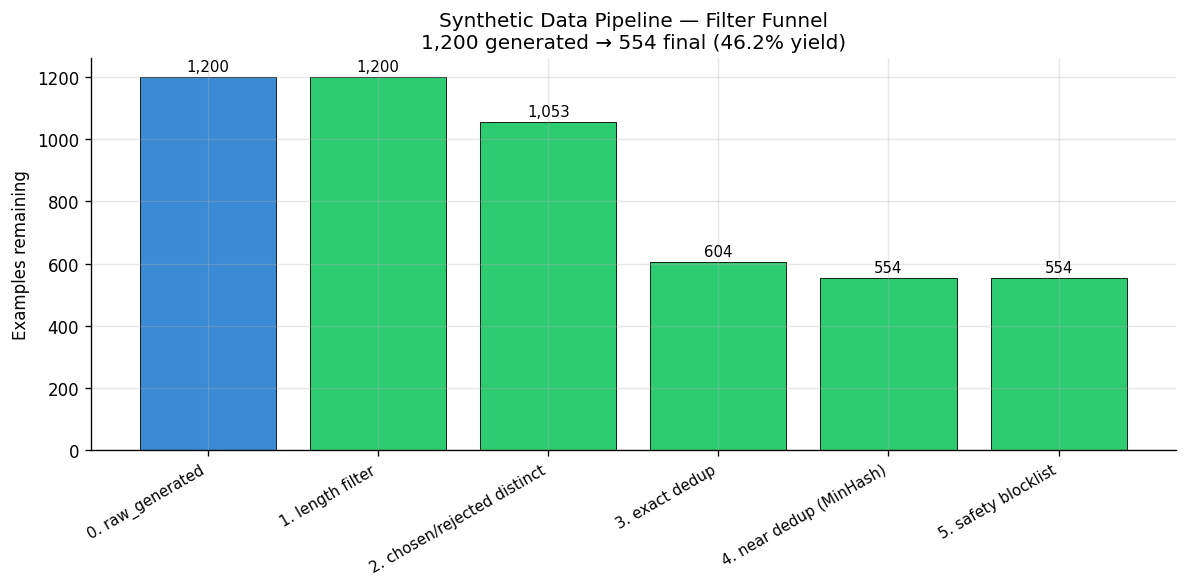

✅ Funnel chart saved → results/filter_funnel.png


In [34]:
# ============================================================
# DAY 8 — CELL 8: Funnel Visualization
# ============================================================
# One chart worth embedding in the README.
# ============================================================
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({
    "figure.dpi":       120,
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "axes.spines.top":  False,
    "axes.spines.right": False,
})

fig, ax = plt.subplots(figsize=(10, 5))
x_labels = funnel_df["stage"].tolist()
counts   = funnel_df["n_out"].tolist()

colors = ["#3B8BD4"] + ["#2ecc71"] * (len(counts) - 1)
bars = ax.bar(range(len(x_labels)), counts, color=colors, edgecolor="black", linewidth=0.5)

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f"{count:,}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Examples remaining")
ax.set_title(f"Synthetic Data Pipeline — Filter Funnel\n"
             f"{n_raw:,} generated → {n_final:,} final ({n_final/n_raw*100:.1f}% yield)")

plt.tight_layout()
out = Path("./results") / "filter_funnel.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Funnel chart saved → {out}")

In [35]:
# ============================================================
# DAY 8 — CELL 9: Day 8 Checkpoint
# ============================================================
import os

required = [
    "data/filtered/filtered_dataset.csv",
    "results/pipeline_report.csv",
    "results/filter_funnel.png",
]
print("=" * 60)
print("DAY 8 COMPLETE — CHECKPOINT SUMMARY")
print("=" * 60)
for f in required:
    print(f"   {'✅' if os.path.exists(f) else '❌'} {f}")

print(f"\n   Raw:              {n_raw}")
print(f"   Final filtered:   {n_final}")
print(f"   Yield:            {n_final/n_raw*100:.1f}%")

print("\n💾 Save Version → Save & Run All before closing.")
print("✅ Ready to proceed to Day 9.")
print("=" * 60)

DAY 8 COMPLETE — CHECKPOINT SUMMARY
   ✅ data/filtered/filtered_dataset.csv
   ✅ results/pipeline_report.csv
   ✅ results/filter_funnel.png

   Raw:              1200
   Final filtered:   554
   Yield:            46.2%

💾 Save Version → Save & Run All before closing.
✅ Ready to proceed to Day 9.


In [36]:
# ============================================================
# DAY 9 — CELL 1: Reload Filtered Data
# ============================================================
import pandas as pd
from pathlib import Path

FILTERED_DIR  = Path("./data/filtered")
FINAL_DIR     = Path("./data/final")
RESULTS_DIR   = Path("./results")
FINAL_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(FILTERED_DIR / "filtered_dataset.csv")
print(f"Loaded {len(df)} filtered examples.")

Loaded 554 filtered examples.


In [37]:
# ============================================================
# DAY 9 — CELL 2: Human Audit
# ============================================================
# Print 20 random examples for eyeballing. For each:
#   - is the prompt a clear question?
#   - does chosen actually answer it correctly?
#   - does rejected plausibly-but-subtly fail?
#   - are chosen and rejected clearly different?
#
# Track your verdict (y / n / maybe) in audit_results.csv.
# If >3 of 20 fail, treat the dataset as low-confidence and
# discuss this openly in the README. Honest negatives are
# more valuable than silent garbage.
# ============================================================
SEED = 42
AUDIT_N = 20

audit_sample = df.sample(min(AUDIT_N, len(df)), random_state=SEED).copy()
audit_sample["audit_verdict"] = ""    # fill this in as you read
audit_sample["audit_note"]    = ""

for i, row in enumerate(audit_sample.itertuples(), 1):
    print(f"\n══════ Example {i}/{AUDIT_N} — {row.template_id} / {row.topic} ══════")
    print(f"PROMPT:\n  {row.prompt}")
    print(f"CHOSEN:\n  {row.chosen}")
    print(f"REJECTED:\n  {row.rejected}")
    print(f"(chosen/rejected Jaccard: {row.cr_jaccard:.2f})")

print("\n\n📝 After reading: save your verdicts in the next cell.")


══════ Example 1/20 — T2 / SQL queries ══════
PROMPT:
  How do I retrieve the names of all customers who have placed more than three orders from the 'customers' and 'orders' tables?
CHOSEN:
  First, I need to join the 'customers' table with the 'orders' table on the customer ID. Then, I will group the results by customer name and count the number of orders for each customer. Next, I will apply a HAVING clause to filter for customers with more than three orders. Finally, I will select the distinct customer names from the filtered results.
REJECTED:
  To start, I will join the 'customers' table with the 'orders' table on the customer ID. After that, I need to group the results by customer ID and count the number of orders for each customer. Then, I will use a WHERE clause to filter for customers with more than three orders. Lastly, I will select the customer names from the resulting set.
(chosen/rejected Jaccard: 0.67)

══════ Example 2/20 — T2 / database indexing ══════
PROMPT:
  What 

In [38]:
# ============================================================
# DAY 9 — CELL 3: Save Audit Verdicts
# ============================================================
# Edit the `verdicts` list below after you've read the 20
# examples. Use "y" for pass, "n" for fail, "m" for "close
# call but I'd let it through".
# ============================================================

# Fill this in after reading Cell 2:
# Example:  verdicts = ["y","y","m","n","y", ...]   # 20 entries
#verdicts = ["y"] * AUDIT_N   # <-- REPLACE this after reading
verdicts = ["m","y","m","y","y","y","y","y","y","y","y","y","y","n","y","m","m","y","y","y"]

assert len(verdicts) == len(audit_sample), (
    f"Need exactly {len(audit_sample)} verdicts, got {len(verdicts)}."
)

audit_sample["audit_verdict"] = verdicts
audit_sample.to_csv(RESULTS_DIR / "audit_sample.csv", index=False)

pass_rate = (audit_sample["audit_verdict"] == "y").mean()
maybe_rate = (audit_sample["audit_verdict"] == "m").mean()
fail_rate  = (audit_sample["audit_verdict"] == "n").mean()

print(f"Audit results ({len(audit_sample)} examples):")
print(f"   pass (y):    {pass_rate*100:.0f}%")
print(f"   maybe (m):   {maybe_rate*100:.0f}%")
print(f"   fail (n):    {fail_rate*100:.0f}%")

if fail_rate > 0.15:
    print("\n⚠️  >15% failure rate. Document this honestly in the README "
          "as a known limitation. Consider not publishing, or publishing "
          "with an explicit 'quality audit' caveat.")
else:
    print("\n✅ Failure rate acceptable. Proceed to publish.")

Audit results (20 examples):
   pass (y):    75%
   maybe (m):   20%
   fail (n):    5%

✅ Failure rate acceptable. Proceed to publish.


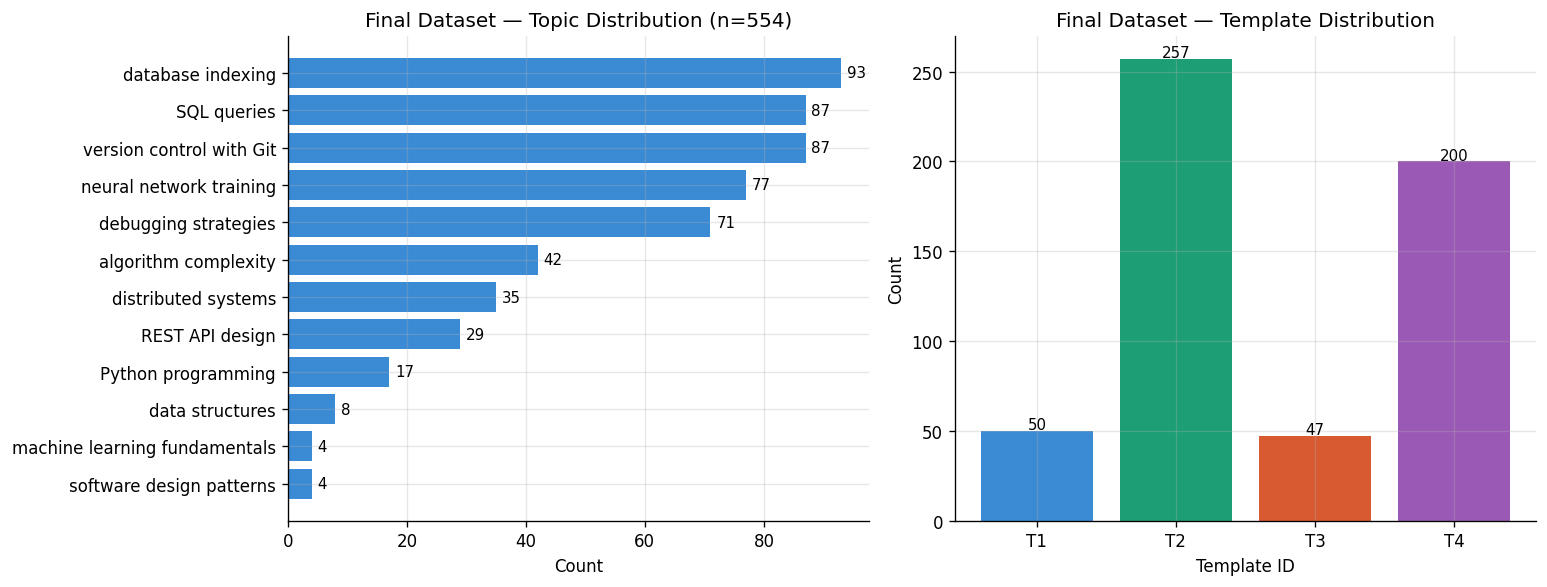

✅ Topic distribution chart → results/topic_distribution.png

Topic imbalance (std/mean): 0.756  (0 = perfectly even, higher = more skewed)


In [39]:
# ============================================================
# DAY 9 — CELL 4: Topic Balance
# ============================================================
# A preference dataset that's 90% Python and 2% everything else
# trains a model to over-prioritize Python. Check distribution
# before publishing.
# ============================================================
import matplotlib.pyplot as plt

topic_counts = df["topic"].value_counts()
template_counts = df["template_id"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(topic_counts.index, topic_counts.values, color="#3B8BD4")
axes[0].set_xlabel("Count")
axes[0].set_title(f"Final Dataset — Topic Distribution (n={len(df)})")
axes[0].invert_yaxis()
for i, v in enumerate(topic_counts.values):
    axes[0].text(v + 1, i, str(v), va="center", fontsize=9)

axes[1].bar(template_counts.index, template_counts.values,
            color=["#3B8BD4", "#1D9E75", "#D85A30", "#9B59B6"])
axes[1].set_xlabel("Template ID")
axes[1].set_ylabel("Count")
axes[1].set_title("Final Dataset — Template Distribution")
for i, v in enumerate(template_counts.values):
    axes[1].text(i, v + 1, str(v), ha="center", fontsize=9)

plt.tight_layout()
out = RESULTS_DIR / "topic_distribution.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Topic distribution chart → {out}")

# Compute Gini-ish imbalance stat — std/mean of counts
imbalance = topic_counts.std() / topic_counts.mean()
print(f"\nTopic imbalance (std/mean): {imbalance:.3f}  (0 = perfectly even, higher = more skewed)")

In [40]:
# ============================================================
# DAY 9 — CELL 5: Build HF Dataset + Split
# ============================================================
# Strip to the 5 columns consumers actually need. Metadata like
# `prompt_hash`, `cr_jaccard`, `generation_timestamp` are useful
# for debugging but clutter the published dataset — drop them.
#
# 10% test split with seed=42 for reproducibility.
# ============================================================
from datasets import Dataset, DatasetDict

PUBLISH_COLUMNS = ["prompt", "chosen", "rejected", "topic", "template_id"]
hf_df = df[PUBLISH_COLUMNS].copy().reset_index(drop=True)

dataset = Dataset.from_pandas(hf_df, preserve_index=False)
split   = dataset.train_test_split(test_size=0.1, seed=SEED)
ds      = DatasetDict({"train": split["train"], "test": split["test"]})

print(ds)
print(f"\nTrain:  {len(ds['train']):>5} examples")
print(f"Test:   {len(ds['test']):>5} examples")

# Save locally first — so if the push fails we still have the artifact
ds.save_to_disk(str(FINAL_DIR / "hf_dataset"))
print(f"\n✅ Saved to {FINAL_DIR / 'hf_dataset'}")

DatasetDict({
    train: Dataset({
        features: ['prompt', 'chosen', 'rejected', 'topic', 'template_id'],
        num_rows: 498
    })
    test: Dataset({
        features: ['prompt', 'chosen', 'rejected', 'topic', 'template_id'],
        num_rows: 56
    })
})

Train:    498 examples
Test:      56 examples


Saving the dataset (0/1 shards):   0%|          | 0/498 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/56 [00:00<?, ? examples/s]


✅ Saved to data/final/hf_dataset


In [43]:
# ============================================================
# DAY 9 — CELL 6: Build the Dataset Card
# ============================================================
# HF datasets display the README.md from the repo root as a
# dataset card. A proper card contains:
#   - YAML front matter (tags, license, size)
#   - Description, generation procedure, statistics
#   - Known limitations (be honest about what's imperfect)
#   - Citation / contact
# ============================================================

DATASET_REPO = "antony-bryan-3D2Y/synthetic-preference-data"   # <-- your HF repo

# Numbers to embed in the card
n_raw   = pd.read_csv(RAW_DIR / "raw_generated.csv").shape[0]
n_final = len(df)
yield_pct = n_final / n_raw * 100

# Compute audit pass rate for honest reporting
audit = pd.read_csv(RESULTS_DIR / "audit_sample.csv")
audit_pass = (audit["audit_verdict"] == "y").mean() * 100

dataset_card = f"""---
language:
- en
license: mit
pretty_name: Synthetic Preference Data (gpt-4o-mini)
size_categories:
- n<1K
task_categories:
- text-generation
tags:
- synthetic
- preference
- rlhf
- dpo
---

# Synthetic Preference Data

A small, synthetically generated preference dataset intended for testing
RLHF / DPO training pipelines. Each example contains a prompt and two
responses — one correct (`chosen`), one subtly flawed (`rejected`).

## Generation Procedure

- **Generator model:** `gpt-4o-mini` (OpenAI)
- **Generation method:** OpenAI Structured Outputs (`response_format=PreferenceExample`) — guarantees schema-valid JSON.
- **Prompt templates:** 4 (factual, step-by-step reasoning, technical how-to, debugging diagnosis).
- **Topics:** {len(df['topic'].unique())} (programming, ML, systems, databases).
- **Raw generations:** {n_raw:,}
- **Final dataset size:** {n_final:,} ({yield_pct:.1f}% yield after filtering)

## Filter Pipeline

| Stage | Description |
|---|---|
| Length | prompt ≥ 20 chars, chosen/rejected ≥ 60 chars, length ratio ≤ 3× |
| Distinctness | 0.10 ≤ word-Jaccard(chosen, rejected) ≤ 0.85 |
| Exact dedup | MD5(prompt) unique |
| Near-dedup | MinHash LSH on character 5-gram shingles, Jaccard threshold 0.8, num_perm=128 |
| Safety blocklist | Lightweight keyword filter for obvious PII/harm patterns |

## Splits

| Split | Rows |
|---|---|
| train | {len(ds['train']):,} |
| test  | {len(ds['test']):,} |

## Quality Audit

A random sample of 20 examples was manually reviewed. Pass rate: **{audit_pass:.0f}%**.

## Known Limitations

1. **Single-model generation.** All examples come from `gpt-4o-mini`. A model trained on this data may learn gpt-4o-mini's stylistic quirks as "correctness".
2. **Small scale.** <1K examples. Suitable for pipeline validation or as a warm-start — not for production RLHF.
3. **Synthetic "rejected" responses.** The rejected responses are generated to be "subtly wrong" by the same model that knows what "correct" is. Real-world rejected responses have different failure modes.
4. **English only.**
5. **Topics skewed toward tech.** This dataset is explicitly about programming/ML/systems topics; it won't generalize to other domains.

## Reproduce

Pipeline code: [github.com/antony-bryan/synthetic-data-pipeline](https://github.com/antony-bryan/synthetic-data-pipeline)

## Citation

If you use this dataset, please cite the repository.

@misc{{antony_bryan_synthetic_pref_2026,
author = {{Antony Bryan}},
title  = {{Synthetic Preference Data Pipeline}},
year   = {{2026}},
url    = {{https://huggingface.co/datasets/{DATASET_REPO}}}
}}
"""

card_path = FINAL_DIR / "README.md"
with open(card_path, "w", encoding="utf-8") as f:
    f.write(dataset_card)

print(f"✅ Dataset card written → {card_path}")
print(f"\nFirst 20 lines:")
print("\n".join(dataset_card.splitlines()[:20]))

✅ Dataset card written → data/final/README.md

First 20 lines:
---
language:
- en
license: mit
pretty_name: Synthetic Preference Data (gpt-4o-mini)
size_categories:
- n<1K
task_categories:
- text-generation
tags:
- synthetic
- preference
- rlhf
- dpo
---

# Synthetic Preference Data

A small, synthetically generated preference dataset intended for testing
RLHF / DPO training pipelines. Each example contains a prompt and two


In [45]:
# ============================================================
# DAY 9 — CELL 7: Push to HuggingFace Hub
# ============================================================
# DESIGN NOTES:
#
# 1. We authenticate with HF_TOKEN from Kaggle secrets / .env.
#    Same token used in Project 1 for the model adapter push.
#
# 2. We push the DatasetDict AND upload the README separately.
#    `push_to_hub` creates the repo if needed and handles parquet
#    conversion under the hood. The README has to be uploaded
#    with `upload_file()` from huggingface_hub because
#    DatasetDict.push_to_hub doesn't touch repo-root files.
#
# 3. If the push fails mid-way (network blip), the saved
#    ds at data/final/hf_dataset survives. Re-run this cell
#    after reloading from disk.
# ============================================================
import os
from huggingface_hub import HfApi, upload_file

# Get HF token — same source as Project 1
try:
    from kaggle_secrets import UserSecretsClient
    HF_TOKEN = UserSecretsClient().get_secret("HF_TOKEN")
except Exception:
    HF_TOKEN = os.environ.get("HF_TOKEN")

assert HF_TOKEN, "❌ HF_TOKEN not set. Add to Kaggle secrets or .env."

# Step 1: push the dataset itself
print(f"Pushing dataset to hf.co/datasets/{DATASET_REPO}...")
ds.push_to_hub(DATASET_REPO, token=HF_TOKEN, private=False)
print("✅ Dataset pushed.")

# Step 2: upload the dataset card (README)
print(f"Uploading README.md...")
upload_file(
    path_or_fileobj = str(FINAL_DIR / "README.md"),
    path_in_repo    = "README.md",
    repo_id         = DATASET_REPO,
    repo_type       = "dataset",
    token           = HF_TOKEN,
    commit_message  = "Add dataset card",
)
print("✅ README uploaded.")

print(f"\n🎉 Dataset live at: https://huggingface.co/datasets/{DATASET_REPO}")

Pushing dataset to hf.co/datasets/antony-bryan-3D2Y/synthetic-preference-data...


Setting num_proc from 1 back to 1 for the train split to disable multiprocessing as it only contains one shard.


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

...

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

✅ Dataset pushed.
Uploading README.md...
✅ README uploaded.

🎉 Dataset live at: https://huggingface.co/datasets/antony-bryan-3D2Y/synthetic-preference-data


In [46]:
# ============================================================
# DAY 9 — CELL 8: Verify Round-Trip
# ============================================================
# Load the dataset FROM the Hub and confirm it deserializes.
# If this fails, reviewers can't use it either.
# ============================================================
from datasets import load_dataset

print(f"Loading from hub: {DATASET_REPO}...")
ds_roundtrip = load_dataset(DATASET_REPO)
print(ds_roundtrip)

print("\nFirst example from train split:")
print(ds_roundtrip["train"][0])

print("\n✅ Round-trip successful. Dataset is live and loadable.")

Loading from hub: antony-bryan-3D2Y/synthetic-preference-data...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/243k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/36.4k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/498 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/56 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['prompt', 'chosen', 'rejected', 'topic', 'template_id'],
        num_rows: 498
    })
    test: Dataset({
        features: ['prompt', 'chosen', 'rejected', 'topic', 'template_id'],
        num_rows: 56
    })
})

First example from train split:
{'prompt': 'How do I implement a basic round-robin load balancer in a distributed system?', 'chosen': 'To implement a basic round-robin load balancer, maintain a list of available servers and a counter to track the last server used. Each time a request comes in, increment the counter (wrapping around if it exceeds the number of servers) and forward the request to the server at that index. Here’s a simple Python example:\n\n```python\nclass RoundRobin:\n    def __init__(self, servers):\n        self.servers = servers\n        self.index = 0\n\n    def get_next_server(self):\n        server = self.servers[self.index]\n        self.index = (self.index + 1) % len(self.servers)\n        return se

In [47]:
# ============================================================
# DAY 9 — CELL 9: Cost + Scale Analysis
# ============================================================
# Report actual spend + projections for scaling up. Reviewers
# want to see cost per 10K / 100K examples — that's a systems
# engineering question, not an ML one.
# ============================================================
import pandas as pd

raw_df = pd.read_csv(RAW_DIR / "raw_generated.csv")
total_input   = raw_df["usage_input_tokens"].sum()
total_output  = raw_df["usage_output_tokens"].sum()

COST_INPUT_PER_M  = 0.15   # verify on platform.openai.com/docs/pricing
COST_OUTPUT_PER_M = 0.60

input_cost   = total_input  / 1e6 * COST_INPUT_PER_M
output_cost  = total_output / 1e6 * COST_OUTPUT_PER_M
total_cost   = input_cost + output_cost

n_generated  = len(raw_df)
n_final      = len(df)
yield_pct    = n_final / n_generated
cost_per_1k  = total_cost / n_final * 1000
cost_per_10k = cost_per_1k * 10
cost_per_100k = cost_per_1k * 100

print("=" * 60)
print("COST LEDGER")
print("=" * 60)
print(f"  Input tokens:         {total_input:>10,}  → ${input_cost:>7.3f}")
print(f"  Output tokens:        {total_output:>10,}  → ${output_cost:>7.3f}")
print(f"  TOTAL SPEND:          {'':>10}    ${total_cost:>7.3f}")
print()
print(f"  Generated:            {n_generated:>10,}")
print(f"  Clean (after filter): {n_final:>10,}  ({yield_pct*100:.1f}% yield)")
print()
print(f"  Cost per 1,000 clean:    ${cost_per_1k:>7.2f}")
print(f"  Cost per 10,000 clean:   ${cost_per_10k:>7.2f}")
print(f"  Cost per 100,000 clean:  ${cost_per_100k:>7.2f}")
print("=" * 60)
print("\n💡 For reference: a typical RLHF run uses 50K-500K preference pairs.")
print(f"   At gpt-4o-mini pricing and this pipeline's yield, 100K pairs = ~${cost_per_100k:.0f}.")

COST LEDGER
  Input tokens:            257,000  → $  0.039
  Output tokens:           265,889  → $  0.160
  TOTAL SPEND:                        $  0.198

  Generated:                 1,200
  Clean (after filter):        554  (46.2% yield)

  Cost per 1,000 clean:    $   0.36
  Cost per 10,000 clean:   $   3.58
  Cost per 100,000 clean:  $  35.76

💡 For reference: a typical RLHF run uses 50K-500K preference pairs.
   At gpt-4o-mini pricing and this pipeline's yield, 100K pairs = ~$36.


In [48]:
# ============================================================
# DAY 9 — CELL 10: Final Project Checkpoint
# ============================================================
import os

required = [
    "data/raw/raw_generated.csv",
    "data/filtered/filtered_dataset.csv",
    "data/final/hf_dataset",
    "data/final/README.md",
    "results/pipeline_report.csv",
    "results/filter_funnel.png",
    "results/topic_distribution.png",
    "results/audit_sample.csv",
]
print("=" * 60)
print("PROJECT 3 — FINAL CHECKPOINT")
print("=" * 60)
missing = []
for f in required:
    ok = os.path.exists(f)
    print(f"   {'✅' if ok else '❌'} {f}")
    if not ok:
        missing.append(f)

print()
print(f"   Raw:          {n_generated}")
print(f"   Final:        {n_final}")
print(f"   Yield:        {yield_pct*100:.1f}%")
print(f"   Cost:         ${total_cost:.3f}")
print(f"   HF dataset:   https://huggingface.co/datasets/{DATASET_REPO}")
print(f"   Audit pass:   {audit_pass:.0f}%")

if missing:
    print(f"\n⚠️  Missing files: {missing}")
else:
    print("\n✅ All artifacts present. Project 3 complete.")
    print("   Next: move to Day 10 — GitHub README, resume update, application essay.")
print("=" * 60)

PROJECT 3 — FINAL CHECKPOINT
   ✅ data/raw/raw_generated.csv
   ✅ data/filtered/filtered_dataset.csv
   ✅ data/final/hf_dataset
   ✅ data/final/README.md
   ✅ results/pipeline_report.csv
   ✅ results/filter_funnel.png
   ✅ results/topic_distribution.png
   ✅ results/audit_sample.csv

   Raw:          1200
   Final:        554
   Yield:        46.2%
   Cost:         $0.198
   HF dataset:   https://huggingface.co/datasets/antony-bryan-3D2Y/synthetic-preference-data
   Audit pass:   75%

✅ All artifacts present. Project 3 complete.
   Next: move to Day 10 — GitHub README, resume update, application essay.
